In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# !pip uninstall -y torch torchvision torchaudio

# !pip install torch==2.2.0 torchvision==0.15.2

In [3]:
pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Download the zip file from Google Drive
import gdown
import os

# link: https://drive.google.com/file/d/1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL/view?usp=sharing
file_id = '1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL
From (redirected): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL&confirm=t&uuid=75d8f750-1a69-49c2-9ead-7c08f4af461b
To: /kaggle/working/archive.zip
100%|██████████| 1.27G/1.27G [00:12<00:00, 99.8MB/s]


'archive.zip'

In [5]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [6]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.virtual_documents', 'test', 'train', 'archive.zip']


In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform=transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset = datasets.ImageFolder(root='train', transform=transform)

In [9]:
# Split the full_dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [10]:
# changed batch size
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


In [11]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [13]:
test_dataset = datasets.ImageFolder(root='test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



In [14]:
def train_model(model, train_loader, val_loader, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'train_accuracy': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted_train = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted_train == labels).sum().item()

        # Validation
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted_val = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted_val == labels).sum().item()

        epoch_train_loss = train_loss/len(train_loader)
        epoch_train_accuracy = 100 * correct_train / total_train
        epoch_val_loss = val_loss/len(val_loader)
        epoch_val_accuracy = 100 * correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_accuracy)
        history['train_accuracy'].append(epoch_train_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {epoch_train_loss:.4f}")
        print(f"Train Accuracy: {epoch_train_accuracy:.2f}%")
        print(f"Val Loss: {epoch_val_loss:.4f}")
        print(f"Val Accuracy: {epoch_val_accuracy:.2f}%\n")
    return history

In [15]:
def evaluate_model(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN3(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN3, self).__init__()

        # First 4 conv layers (NO pooling)
        self.conv1 = nn.Conv2d(3, 1028, 3)
        self.conv2 = nn.Conv2d(1028, 512, 3)
        self.conv3 = nn.Conv2d(512, 256, 3)
        self.conv4 = nn.Conv2d(256, 128, 3)

        # Last 4 conv layers (WITH pooling)
        self.conv5 = nn.Conv2d(128, 64, 3)
        self.conv6 = nn.Conv2d(64, 32, 3)
        self.conv7 = nn.Conv2d(32, 16, 3)
        self.conv8 = nn.Conv2d(16, 8, 3)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔥 Use adaptive pooling to FORCE (2×2) as paper says
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # Now flatten = 8 × 2 × 2 = 32
        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        # No pooling
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))

        # With pooling
        x = self.pool(F.relu(self.conv5(x)))
        x = self.pool(F.relu(self.conv6(x)))
        x = self.pool(F.relu(self.conv7(x)))
        x = self.pool(F.relu(self.conv8(x)))

        # 🔥 Force final shape (2×2)
        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)  # → 32

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model4 = CustomCNN3(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [18]:
total_params = sum(p.numel() for p in model4.parameters())
print("Total parameters:", total_params)

Total parameters: 6360556


In [19]:
history3=train_model(model4, train_loader, val_loader, epochs=15)

Epoch [1/15]
Train Loss: 0.5963
Train Accuracy: 74.79%
Val Loss: 0.4282
Val Accuracy: 83.28%

Epoch [2/15]
Train Loss: 0.4129
Train Accuracy: 83.85%
Val Loss: 0.3322
Val Accuracy: 86.54%

Epoch [3/15]
Train Loss: 0.3153
Train Accuracy: 87.14%
Val Loss: 0.4245
Val Accuracy: 86.40%

Epoch [4/15]
Train Loss: 0.2872
Train Accuracy: 87.90%
Val Loss: 0.3312
Val Accuracy: 86.21%

Epoch [5/15]
Train Loss: 0.2595
Train Accuracy: 88.91%
Val Loss: 0.1960
Val Accuracy: 91.10%

Epoch [6/15]
Train Loss: 0.2220
Train Accuracy: 90.68%
Val Loss: 0.1593
Val Accuracy: 93.99%

Epoch [7/15]
Train Loss: 0.2042
Train Accuracy: 92.13%
Val Loss: 0.2723
Val Accuracy: 89.24%

Epoch [8/15]
Train Loss: 0.1744
Train Accuracy: 93.49%
Val Loss: 0.1524
Val Accuracy: 94.46%

Epoch [9/15]
Train Loss: 0.1612
Train Accuracy: 94.05%
Val Loss: 0.1963
Val Accuracy: 91.94%

Epoch [10/15]
Train Loss: 0.1364
Train Accuracy: 95.24%
Val Loss: 0.1282
Val Accuracy: 94.69%

Epoch [11/15]
Train Loss: 0.0905
Train Accuracy: 96.93%
Val

In [20]:
preds, labels = evaluate_model(model4, test_loader)

Test Loss: 0.0592
Test Accuracy: 98.26%


In [21]:
import matplotlib.pyplot as plt

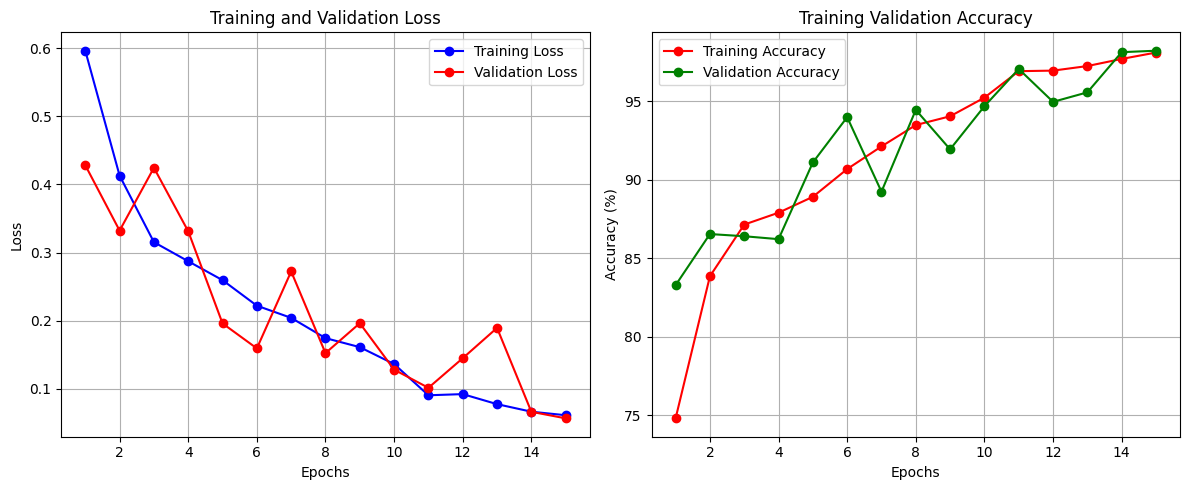

In [22]:
epochs = range(1, len(history3['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, history3['train_loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history3['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, history3['train_accuracy'], 'ro-', label='Training Accuracy')
plt.plot(epochs, history3['val_accuracy'], 'go-', label='Validation Accuracy')
plt.title('Training Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
torch.save(model4.state_dict(), "Custommodel3_fp32.pth")

In [25]:
from google.colab import files

files.download("Custommodel3_fp32.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>